In [2]:
import pandas as pd


In [3]:
data = {

    "name" : ["Alice","Bob","Charlie","David","Eva"],
    "age" : [25,30,35,40,28],
    "salary" : [50000,60000,70000,80000,52000],
    "department" : ["HR","IT","IT","Finance","HR"]
}

df = pd.DataFrame(data)

In [4]:
df.head()

,name,age,salary,department
0,Alice,25,50000,HR
1,Bob,30,60000,IT
2,Charlie,35,70000,IT
3,David,40,80000,Finance
4,Eva,28,52000,HR


In [5]:
df.head(3)

,name,age,salary,department
0,Alice,25,50000,HR
1,Bob,30,60000,IT
2,Charlie,35,70000,IT


In [6]:
df.columns

Index(['name', 'age', 'salary', 'department'], dtype='str')

In [7]:
df.loc[:,["name","age"]]

,name,age
0,Alice,25
1,Bob,30
2,Charlie,35
3,David,40
4,Eva,28


In [8]:
df[df["age"] > 30]

,name,age,salary,department
2,Charlie,35,70000,IT
3,David,40,80000,Finance


In [9]:
df.describe()

,age,salary
count,5.00000,5.000000
mean,31.60000,62400.000000
std,5.94138,12601.587202
min,25.00000,50000.000000
25%,28.00000,52000.000000
50%,30.00000,60000.000000
75%,35.00000,70000.000000
max,40.00000,80000.000000


In [10]:
df["salary"].mean().round(2)

np.float64(62400.0)

In [11]:
df

,name,age,salary,department
0,Alice,25,50000,HR
1,Bob,30,60000,IT
2,Charlie,35,70000,IT
3,David,40,80000,Finance
4,Eva,28,52000,HR


In [12]:
df["salary"].max()

np.int64(80000)

In [13]:
df["department"].value_counts()

department
HR         2
IT         2
Finance    1
Name: count, dtype: int64

In [14]:
df.sort_values("salary",ascending=False)

,name,age,salary,department
3,David,40,80000,Finance
2,Charlie,35,70000,IT
1,Bob,30,60000,IT
4,Eva,28,52000,HR
0,Alice,25,50000,HR


In [15]:
df[df["department"] == "IT"]

,name,age,salary,department
1,Bob,30,60000,IT
2,Charlie,35,70000,IT


In [16]:
df[(df["salary"] > 55000) & (df["age"] < 35)]

,name,age,salary,department
1,Bob,30,60000,IT


In [17]:
df["bonus"] = df["salary"] * 0.1

In [18]:
df

,name,age,salary,department,bonus
0,Alice,25,50000,HR,5000.0
1,Bob,30,60000,IT,6000.0
2,Charlie,35,70000,IT,7000.0
3,David,40,80000,Finance,8000.0
4,Eva,28,52000,HR,5200.0


In [19]:
import numpy as np

In [20]:
df["department"]= np.where(df["department"] == "HR","Human Resources",df["department"])

In [21]:
df

,name,age,salary,department,bonus
0,Alice,25,50000,Human Resources,5000.0
1,Bob,30,60000,IT,6000.0
2,Charlie,35,70000,IT,7000.0
3,David,40,80000,Finance,8000.0
4,Eva,28,52000,Human Resources,5200.0


In [22]:
df.rename(columns={"name":"employee_name"})

,employee_name,age,salary,department,bonus
0,Alice,25,50000,Human Resources,5000.0
1,Bob,30,60000,IT,6000.0
2,Charlie,35,70000,IT,7000.0
3,David,40,80000,Finance,8000.0
4,Eva,28,52000,Human Resources,5200.0


In [23]:
df.groupby(df["department"]).agg({"salary":"mean"})

,salary
department,
Finance,80000.0
Human Resources,51000.0
IT,65000.0


In [24]:
df

,name,age,salary,department,bonus
0,Alice,25,50000,Human Resources,5000.0
1,Bob,30,60000,IT,6000.0
2,Charlie,35,70000,IT,7000.0
3,David,40,80000,Finance,8000.0
4,Eva,28,52000,Human Resources,5200.0


In [25]:
df.groupby(df["department"]).agg({"name":"count"})

,name
department,
Finance,1
Human Resources,2
IT,2


In [26]:
df.groupby(df["department"]).agg({"salary":"max"})

,salary
department,
Finance,80000
Human Resources,52000
IT,70000


In [27]:
df.groupby(df["department"]).agg({
    "salary":["max","mean"],
    "name":"count"
})

salary           name
                   max     mean count
department                           
Finance          80000  80000.0     1
Human Resources  52000  51000.0     2
IT               70000  65000.0     2

In [28]:
df.groupby("department")["salary"].mean().sort_values(ascending=False)

department
Finance            80000.0
IT                 65000.0
Human Resources    51000.0
Name: salary, dtype: float64

In [29]:
data1 = {
    "order_id" : [1,2,3,4,5,6],
    "customer" : ["A","B","A","C","B","A"],
    "amount" : [100,200,150,300,250,120],
    "city" : ["Chennai","Delhi","Chennai","Mumbai","Delhi","Chennai"]
}


lvl = pd.DataFrame(data1)

In [30]:
lvl.head()

,order_id,customer,amount,city
0,1,A,100,Chennai
1,2,B,200,Delhi
2,3,A,150,Chennai
3,4,C,300,Mumbai
4,5,B,250,Delhi


In [31]:
lvl.groupby("customer")["amount"].sum()

customer
A    370
B    450
C    300
Name: amount, dtype: int64

In [33]:
lvl.groupby("city")["order_id"].count()

city
Chennai    3
Delhi      2
Mumbai     1
Name: order_id, dtype: int64

In [35]:
lvl.groupby("city")["amount"].mean().round(2)

city
Chennai    123.33
Delhi      225.00
Mumbai     300.00
Name: amount, dtype: float64

In [38]:
lvl.groupby("customer")["amount"].sum().idxmax()

'B'

In [41]:
lvl.groupby("city")["amount"].sum().sort_values(ascending=False).head(1)

city
Delhi    450
Name: amount, dtype: int64

In [42]:
lvl.groupby("city")["amount"].sum().idxmax()

'Delhi'

In [43]:
def classify(row):
    if row < 150:
        return "low"
    elif 150 <= row <= 250:
        return "medium"
    else:
        return "High"
    

lvl["amount_category"] = lvl["amount"].apply(classify)

In [44]:
lvl

,order_id,customer,amount,city,amount_category
0,1,A,100,Chennai,low
1,2,B,200,Delhi,medium
2,3,A,150,Chennai,medium
3,4,C,300,Mumbai,High
4,5,B,250,Delhi,medium
5,6,A,120,Chennai,low


In [45]:
lvl[lvl.duplicated("customer")]

,order_id,customer,amount,city,amount_category
2,3,A,150,Chennai,medium
4,5,B,250,Delhi,medium
5,6,A,120,Chennai,low


In [46]:
lvl = lvl.drop_duplicates("customer")

In [47]:
lvl

,order_id,customer,amount,city,amount_category
0,1,A,100,Chennai,low
1,2,B,200,Delhi,medium
3,4,C,300,Mumbai,High


In [48]:
lvl["rank"] = lvl["amount"].rank(ascending=False,method="dense").astype(int)

In [49]:
lvl

,order_id,customer,amount,city,amount_category,rank
0,1,A,100,Chennai,low,3
1,2,B,200,Delhi,medium,2
3,4,C,300,Mumbai,High,1


In [50]:
lvl["expanding_sum"]  = lvl["amount"].expanding().sum()

In [51]:
lvl

,order_id,customer,amount,city,amount_category,rank,expanding_sum
0,1,A,100,Chennai,low,3,100.0
1,2,B,200,Delhi,medium,2,300.0
3,4,C,300,Mumbai,High,1,600.0


In [9]:
import pandas as pd
dfd = pd.DataFrame({
    "temp": [30, None, None, 32, None, 35]
})
dfd.ffill(inplace=True)

,temp
0,30.0
1,30.0
2,30.0
3,32.0
4,32.0
5,35.0


In [18]:
df = pd.DataFrame({
    "price" : [100,200,300],
    "qty" : [2,1,5]
})
df.assign(
    total = df["price"] * df["qty"],
    discounted =  lambda x : x["total"] * 0.9
)

,price,qty,total,discounted
0,100,2,200,180.0
1,200,1,200,180.0
2,300,5,1500,1350.0


In [19]:
df = pd.DataFrame({
    "name" : ["A","B","C","D"],
    "marks" : [40,85,60,30]
})
df.query("marks > 50")

,name,marks
1,B,85
2,C,60


In [22]:
df = pd.DataFrame({
    "dept": ["IT","IT","HR","HR"],
    "salary": [50, 60, 40, 45]
})
df["avg_salary_per_dept"] = df.groupby("dept")["salary"].transform("mean")
df

,dept,salary,avg_salary_per_dept
0,IT,50,55.0
1,IT,60,55.0
2,HR,40,42.5
3,HR,45,42.5


In [ ]:
df = pd.DataFrame({
    "name": ["A","B","C","D"],
    "score": [90, 80, 90, 70]
})
df["rank"] = df["score"].rank(method="dense",ascending=False)
df

,name,score,rank
0,A,90,3.0
1,B,80,2.0
2,C,90,3.0
3,D,70,1.0


In [29]:
df = pd.DataFrame({
    "sales": [100, 120, 90, 150]
})
df.assign(
    prev_sales = df["sales"].shift(1),
    growth = lambda x : x["sales"] - x["prev_sales"]
)

,sales,prev_sales,growth
0,100,NaN,NaN
1,120,100.0,20.0
2,90,120.0,-30.0
3,150,90.0,60.0


In [31]:
df = pd.DataFrame({
    "sales": [10, 20, 30, 40, 50]
})
df.rolling(3).mean().tail(1)

,sales
4,40.0


In [35]:
df = pd.DataFrame({
    "region": ["A","A","B","B"],
    "product": ["X","Y","X","Y"],
    "sales": [100, 200, 150, 250]
})

df.pivot_table(index= "product",columns="region",values="sales",aggfunc="sum")

region,A,B
product,,
X,100,150
Y,200,250


In [39]:
df = pd.DataFrame({
    "email": ["a@gmail.com", "b@yahoo.com", "c@gmail.com"]
})
df[df["email"].str.contains("gmail")]
df["email"].str.upper()


0    A@GMAIL.COM
1    B@YAHOO.COM
2    C@GMAIL.COM
Name: email, dtype: str

In [42]:
dfg = pd.DataFrame({
    "dept": ["IT","IT","HR","HR","IT"],
    "salary": [50, None, 40, 45, None]
})
dfg.ffill(inplace=True)

,dept,salary
0,IT,50.0
1,IT,50.0
2,HR,40.0
3,HR,45.0
4,IT,45.0


In [44]:
dfg["avg_salary"] = dfg.groupby("dept")["salary"].transform("mean").round(2)

In [46]:
dfg["rank"] = dfg["salary"].rank(method="dense",ascending=False)

In [47]:
dfg

,dept,salary,avg_salary,rank
0,IT,50.0,48.33,1.0
1,IT,50.0,48.33,1.0
2,HR,40.0,42.50,3.0
3,HR,45.0,42.50,2.0
4,IT,45.0,48.33,2.0


In [48]:
import pandas as pd

df = pd.DataFrame({
    "name": ["A","B","C","D"],
    "marks": [90, 40, 80, 60],
    "city": ["Chennai","Delhi","Chennai","Mumbai"]
})

In [49]:
df.query("marks > 50")

,name,marks,city
0,A,90,Chennai
2,C,80,Chennai
3,D,60,Mumbai


In [50]:
import numpy as np
df["result"] = np.where(df["marks"] > 50,"Passed","Failed")

In [51]:
df.sort_values("marks",ascending=False)

,name,marks,city,result
0,A,90,Chennai,Passed
2,C,80,Chennai,Passed
3,D,60,Mumbai,Passed
1,B,40,Delhi,Failed


In [52]:
df.groupby("city")["name"].count()

city
Chennai    2
Delhi      1
Mumbai     1
Name: name, dtype: int64

In [59]:
df["marks"] = df["marks"].apply(lambda x : None if x < 50 else x)

In [60]:
df

,name,marks,city,result
0,A,90.0,Chennai,Passed
1,B,NaN,Delhi,Failed
2,C,80.0,Chennai,Passed
3,D,60.0,Mumbai,Passed


In [61]:
df["city"].value_counts()

city
Chennai    2
Delhi      1
Mumbai     1
Name: count, dtype: int64

In [62]:
df = pd.DataFrame({
    "name": ["A","B","B","C"],
    "marks": [90, None, None, 80],
    "city": ["Chennai","Delhi","Delhi",None]
})

In [63]:
df.drop_duplicates()

,name,marks,city
0,A,90.0,Chennai
1,B,NaN,Delhi
3,C,80.0,NaN


In [64]:
df["marks"] = df["marks"].fillna(df["marks"].mean())

In [78]:
df["city"] = df["city"].apply(lambda x : "Unkown" if pd.isnull(x) else x)

In [66]:
df.describe()

,marks
count,4.000000
mean,85.000000
std,4.082483
min,80.000000
25%,83.750000
50%,85.000000
75%,86.250000
max,90.000000


In [70]:
df.dtypes

name         str
marks    float64
city         str
dtype: object

In [ ]:
df["marks"] = df["marks"].astype(int)

In [73]:
df

,name,marks,city
0,A,90,Chennai
1,B,85,Delhi
2,B,85,Delhi
3,C,80,NaN


In [74]:
df.isnull().sum()

name     0
marks    0
city     1
dtype: int64

In [75]:
df

,name,marks,city
0,A,90,Chennai
1,B,85,Delhi
2,B,85,Delhi
3,C,80,NaN


In [2]:
import pandas as pd
import numpy as np

df = pd.DataFrame({
    "a": [1, None, np.nan, 4]
})



In [3]:
df.isnull()

,a
0,False
1,True
2,True
3,False


In [4]:
df = df.fillna(0)

In [5]:
df

,a
0,1.0
1,0.0
2,0.0
3,4.0


In [6]:
df["a"] = df["a"].astype(int)

In [9]:
df[df["a"].isnull()]

,a


In [2]:
import pandas as pd
df = pd.DataFrame({
    "dept": ["IT","IT","HR","HR","IT"],
    "salary": [50, 60, 40, 45, 55],
    "employee": ["A","B","C","D","E"]
})

In [3]:
df.groupby("dept")["salary"].mean()

dept
HR    42.5
IT    55.0
Name: salary, dtype: float64

In [4]:
df.groupby("dept")["salary"].sum()

dept
HR     85
IT    165
Name: salary, dtype: int64

In [5]:
df["dept"].value_counts()

dept
IT    3
HR    2
Name: count, dtype: int64

In [14]:
df.loc[df.groupby("dept")["salary"].idxmax()]

,dept,salary,employee
3,HR,45,D
1,IT,60,B


In [21]:
df["rank"] = df.groupby("dept")["salary"].rank(method = "dense",ascending=False).astype(int)

In [22]:
df

,dept,salary,employee,rank
0,IT,50,A,3
1,IT,60,B,1
2,HR,40,C,2
3,HR,45,D,1
4,IT,55,E,2


In [23]:
df.sort_values("salary", ascending=False).drop_duplicates("dept")

,dept,salary,employee,rank
1,IT,60,B,1
3,HR,45,D,1


In [28]:
employees = pd.DataFrame({
    "id": [1,2,3,4],
    "name": ["A","B","C","D"]
})

salary = pd.DataFrame({
    "id": [1,2,4],
    "salary": [1000,2000,3000]
})

In [33]:
new = pd.merge(employees,salary,on = "id",how="left").copy()

In [34]:
new

,id,name,salary
0,1,A,1000.0
1,2,B,2000.0
2,3,C,NaN
3,4,D,3000.0


In [45]:
new

,id,name,salary
0,1,A,1000.0
1,2,B,2000.0
2,3,C,C
3,4,D,3000.0


In [51]:
new.loc[2,"salary"] = pd.NA

In [52]:
new

,id,name,salary
0,1,A,1000.0
1,2,B,2000.0
2,3,C,<NA>
3,4,D,3000.0


In [53]:
new[new["salary"].isnull()]

,id,name,salary
2,3,C,<NA>


In [55]:
outer = pd.merge(employees,salary,on = "id",how = "outer")

In [56]:
outer

,id,name,salary
0,1,A,1000.0
1,2,B,2000.0
2,3,C,NaN
3,4,D,3000.0


In [57]:
outer["has_salary"] = new["salary"].notnull()

In [58]:
outer

,id,name,salary,has_salary
0,1,A,1000.0,True
1,2,B,2000.0,True
2,3,C,NaN,False
3,4,D,3000.0,True


In [59]:
df = pd.DataFrame({
    "dept": ["IT","IT","HR","HR","IT"],
    "salary": [50, 60, 40, 45, 55]
})

In [63]:
df["roll"] = df["salary"].rolling(2).sum()

In [64]:
df

,dept,salary,roll
0,IT,50,NaN
1,IT,60,110.0
2,HR,40,100.0
3,HR,45,85.0
4,IT,55,100.0


In [67]:
df["avg_rolldf"] = df["salary"].rolling(2).mean()

In [68]:
df

,dept,salary,roll,avg_rolldf
0,IT,50,NaN,NaN
1,IT,60,110.0,55.0
2,HR,40,100.0,50.0
3,HR,45,85.0,42.5
4,IT,55,100.0,50.0


In [69]:
df["rank"] = df.groupby("dept")["salary"].rank(method="dense",ascending=False)

In [70]:
df

,dept,salary,roll,avg_rolldf,rank
0,IT,50,NaN,NaN,3.0
1,IT,60,110.0,55.0,1.0
2,HR,40,100.0,50.0,2.0
3,HR,45,85.0,42.5,1.0
4,IT,55,100.0,50.0,2.0


In [71]:
df["prev_salary"] = df["salary"].shift(1)

In [72]:
df["difference"] = df["salary"] - df["prev_salary"]

In [78]:
df["cum_max"] = df["salary"].cummax()

In [76]:
df

,dept,salary,roll,avg_rolldf,rank,prev_salary,difference,cum_max
0,IT,50,NaN,NaN,3.0,NaN,NaN,50
1,IT,60,110.0,55.0,1.0,50.0,10.0,60
2,HR,40,100.0,50.0,2.0,60.0,-20.0,60
3,HR,45,85.0,42.5,1.0,40.0,5.0,60
4,IT,55,100.0,50.0,2.0,45.0,10.0,60


In [79]:
df = pd.DataFrame({
    "name": ["A","A","B","B"],
    "subject": ["Math","Sci","Math","Sci"],
    "marks": [90,80,70,60]
})

In [80]:
df.pivot_table(index = "name",columns="subject",values="marks")

subject,Math,Sci
name,,
A,90.0,80.0
B,70.0,60.0


In [ ]:
df.pivot(index="name",columns="subject",values="marks")

subject,Math,Sci
name,,
A,90,80
B,70,60


In [40]:
df = pd.DataFrame({
    "student": ["A","A","B","B","C"],
    "marks": [90,85,80,95,70]
})

In [41]:
import pandas as pd

In [43]:
df.loc[df.groupby("student")["marks"].idxmax()]

,student,marks
0,A,90
3,B,95
4,C,70


In [6]:
df.loc[df["marks"].idxmax()]

student     B
marks      95
Name: 3, dtype: object

In [7]:
df = pd.DataFrame({
    "region": ["East","West","East","West","East"],
    "sales": [100,200,150,300,120]
})

In [9]:
df.groupby("region")["sales"].max()

region
East    150
West    300
Name: sales, dtype: int64

In [11]:
df.loc[df["region"].idxmax()]

region    West
sales      200
Name: 1, dtype: object

In [13]:
import matplotlib.pyplot as plt

([<matplotlib.patches.Wedge at 0x767a3b462270>,
 [Text(-0.38863668077380875, 1.0290585650764084, 'East'),
  Text(-1.0912263288261013, 0.1386546042391297, 'West'),
  Text(-0.46187825807823985, -0.9983328476588412, 'East'),
  Text(1.0218743465557247, -0.4071520844246171, 'West'),
  Text(0.46187888486441286, 0.9983325576762518, 'East')],
 [Text(-0.21198364405844114, 0.5613046718598591, '11.5%'),
  Text(-0.5952143611778733, 0.07562978413043438, '23.0%'),
  Text(-0.2519335953154035, -0.5445451896320952, '17.2%'),
  Text(0.5573860072122134, -0.2220829551407002, '34.5%'),
  Text(0.2519339371987706, 0.5445450314597736, '13.8%')])

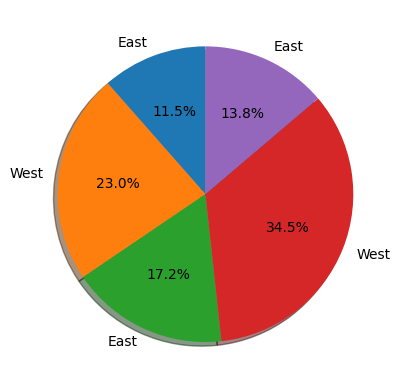

In [23]:
plt.pie(df["sales"],
        labels= df["region"],
        shadow = True,
        autopct="%1.1f%%",
        startangle=90,
        )

In [45]:
df = pd.DataFrame({
    "dept": ["IT","IT","HR","HR"],
    "salary": [50,None,40,None]
})

In [46]:
df["salary"] = df["salary"].fillna(df.groupby("dept")["salary"].transform("mean"))

In [47]:
df

,dept,salary
0,IT,50.0
1,IT,50.0
2,HR,40.0
3,HR,40.0


In [29]:
meee = df.groupby("dept")["salary"].mean()

In [30]:
df["salary"] = df["salary"].fillna(meee)

In [32]:
df.isnull()

,dept,salary
0,False,False
1,False,True
2,False,False
3,False,True


In [33]:
df = pd.DataFrame({
    "user": ["A","A","B","B","C"],
    "day": [1,2,1,3,2],
    "score": [10,20,15,25,30]
})

In [ ]:
df.groupby("user")["score"].sum()

user
A    30
B    40
C    30
Name: score, dtype: int64

In [35]:
df.groupby("user")["score"].last()

user
A    20
B    25
C    30
Name: score, dtype: int64

In [36]:
df["growth"] = df["score"].diff()

In [37]:
df

,user,day,score,growth
0,A,1,10,NaN
1,A,2,20,10.0
2,B,1,15,-5.0
3,B,3,25,10.0
4,C,2,30,5.0


In [48]:
df = pd.DataFrame({
    "dept": ["IT","IT","HR","HR","IT"],
    "salary": [50,None,40,45,None]
})

In [50]:
df["salary"] = df["salary"].ffill()

In [58]:
df.groupby("dept")["salary"].mean().round(2)

dept
HR    42.50
IT    48.33
Name: salary, dtype: float64

In [59]:
df.groupby("dept")["salary"].rank(method="dense",ascending=False)

0    1.0
1    1.0
2    2.0
3    1.0
4    2.0
Name: salary, dtype: float64

In [ ]:
df.loc[df["salary"] > df.groupby("dept")["salary"].mean().round(2)]

ValueError: Can only compare identically-labeled Series objects

array([42.5 , 48.33])

In [62]:
df = pd.DataFrame({
    "marks": [40, 60, 80, 100]
})

In [63]:
min_val = df["marks"].min()

In [64]:
max_val = df["marks"].max()

In [ ]:
df["norm_marks"] = (df["marks"] - min_val) / ( max_val - min_val)

In [68]:
df["marks"].dtype

dtype('int64')

In [69]:
df["norm_marks"] = (df["marks"] - min_val) / (max_val - min_val)

In [70]:
df

,marks,norm_marks
0,40,0.000000
1,60,0.333333
2,80,0.666667
3,100,1.000000


In [95]:
df = pd.DataFrame({
    "dept": ["IT","IT","HR","HR"],
    "salary": [50, 60, 40, 45]
})

In [96]:
df["dept_avg"] = df.groupby("dept")["salary"].transform("mean")

In [97]:
df

,dept,salary,dept_avg
0,IT,50,55.0
1,IT,60,55.0
2,HR,40,42.5
3,HR,45,42.5


In [98]:
df["above_avg"] = df["salary"] > df["dept_avg"]

In [99]:
df["norm_sal"] = (df["salary"] - df["salary"].min()) / (df["salary"].max() - df["salary"].min())

In [100]:
df

,dept,salary,dept_avg,above_avg,norm_sal
0,IT,50,55.0,False,0.50
1,IT,60,55.0,True,1.00
2,HR,40,42.5,False,0.00
3,HR,45,42.5,True,0.25


In [81]:
df = pd.DataFrame({
    "dept": ["IT","IT","HR","HR","IT"],
    "salary": [50, 60, 40, 45, 55]
})

In [88]:
df.loc[df.groupby("dept")["salary"].idxmax(2)]

,dept,salary
3,HR,45
1,IT,60


In [89]:
df = pd.DataFrame({
    "user": ["A","A","A","B","B"],
    "score": [10,20,15,5,25]
})

In [ ]:
df.groupby("user")["score"].sum()

user
A    45
B    30
Name: score, dtype: int64

In [3]:
import pandas as pd
df = pd.DataFrame({
    "dept": ["IT","IT","HR","HR","IT"],
    "salary": [50,None,40,45,None]
})

In [4]:
df["salary"] = df["salary"].fillna(df.groupby("dept")["salary"].transform("mean"))

In [5]:
df

,dept,salary
0,IT,50.0
1,IT,50.0
2,HR,40.0
3,HR,45.0
4,IT,50.0


In [6]:
df["dept_avg"] = df.groupby("dept")["salary"].transform("mean")

In [7]:
df

,dept,salary,dept_avg
0,IT,50.0,50.0
1,IT,50.0,50.0
2,HR,40.0,42.5
3,HR,45.0,42.5
4,IT,50.0,50.0


In [8]:
df["sal>avg_sal"] = df["salary"] > df["dept_avg"]

In [9]:
df

,dept,salary,dept_avg,sal>avg_sal
0,IT,50.0,50.0,False
1,IT,50.0,50.0,False
2,HR,40.0,42.5,False
3,HR,45.0,42.5,True
4,IT,50.0,50.0,False


In [10]:
df["rank"] = df.groupby("dept")["salary"].rank(method="first",ascending=False).astype(int)

In [11]:
df

,dept,salary,dept_avg,sal>avg_sal,rank
0,IT,50.0,50.0,False,1
1,IT,50.0,50.0,False,2
2,HR,40.0,42.5,False,2
3,HR,45.0,42.5,True,1
4,IT,50.0,50.0,False,3


In [12]:
df["norm_sal"] = df.groupby("dept")["salary"].transform(
    lambda x : (x - x.min()) / (x.max() - x.min())
)

In [13]:
df

,dept,salary,dept_avg,sal>avg_sal,rank,norm_sal
0,IT,50.0,50.0,False,1,NaN
1,IT,50.0,50.0,False,2,NaN
2,HR,40.0,42.5,False,2,0.0
3,HR,45.0,42.5,True,1,1.0
4,IT,50.0,50.0,False,3,NaN


In [14]:
df = pd.DataFrame({
    "user": ["A","A","A","B","B","C"],
    "day": [1,2,3,1,2,1],
    "score": [10,20,15,5,25,30]
})

In [15]:
df["run_per_user"] = df.groupby("user")["score"].cumsum()

In [16]:
df

,user,day,score,run_per_user
0,A,1,10,10
1,A,2,20,30
2,A,3,15,45
3,B,1,5,5
4,B,2,25,30
5,C,1,30,30


In [17]:
df["percent"] = (df["score"] / df.groupby("user")["score"].transform("sum")).round(2)

In [18]:
df

,user,day,score,run_per_user,percent
0,A,1,10,10,0.22
1,A,2,20,30,0.44
2,A,3,15,45,0.33
3,B,1,5,5,0.17
4,B,2,25,30,0.83
5,C,1,30,30,1.00


In [19]:
df["rank"] = df.groupby("user")["score"].rank(method="dense",ascending=False).astype(int)

In [20]:
df

,user,day,score,run_per_user,percent,rank
0,A,1,10,10,0.22,3
1,A,2,20,30,0.44,1
2,A,3,15,45,0.33,2
3,B,1,5,5,0.17,2
4,B,2,25,30,0.83,1
5,C,1,30,30,1.00,1


In [21]:
df["diff"] = df["score"].diff()

In [22]:
df

,user,day,score,run_per_user,percent,rank,diff
0,A,1,10,10,0.22,3,NaN
1,A,2,20,30,0.44,1,10.0
2,A,3,15,45,0.33,2,-5.0
3,B,1,5,5,0.17,2,-10.0
4,B,2,25,30,0.83,1,20.0
5,C,1,30,30,1.00,1,5.0


In [23]:
df.groupby("user")["score"].last().idxmax()

'C'

In [24]:
df

,user,day,score,run_per_user,percent,rank,diff
0,A,1,10,10,0.22,3,NaN
1,A,2,20,30,0.44,1,10.0
2,A,3,15,45,0.33,2,-5.0
3,B,1,5,5,0.17,2,-10.0
4,B,2,25,30,0.83,1,20.0
5,C,1,30,30,1.00,1,5.0


In [25]:
import matplotlib.pyplot as plt

<Axes: xlabel='user'>

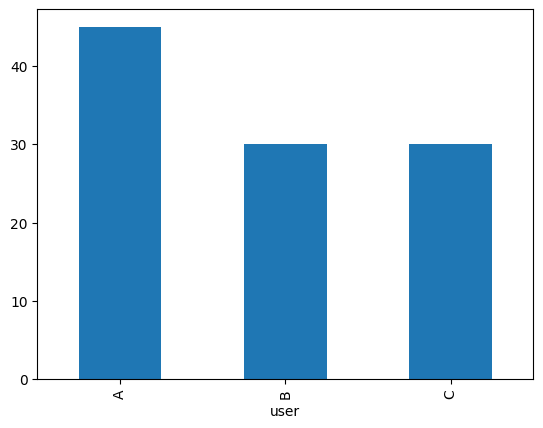

In [26]:
df.groupby("user")["score"].sum().plot(kind = "bar")

user
A    Axes(0.125,0.11;0.775x0.77)
B    Axes(0.125,0.11;0.775x0.77)
C    Axes(0.125,0.11;0.775x0.77)
Name: score, dtype: object

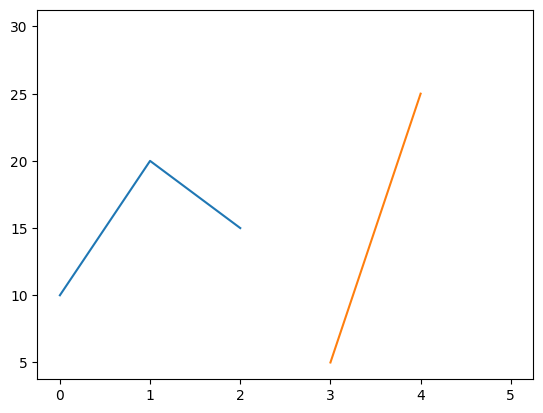

In [27]:
df.groupby("user")["score"].plot(kind = "line")

user
A    Axes(0.125,0.11;0.775x0.77)
B    Axes(0.125,0.11;0.775x0.77)
C    Axes(0.125,0.11;0.775x0.77)
Name: score, dtype: object

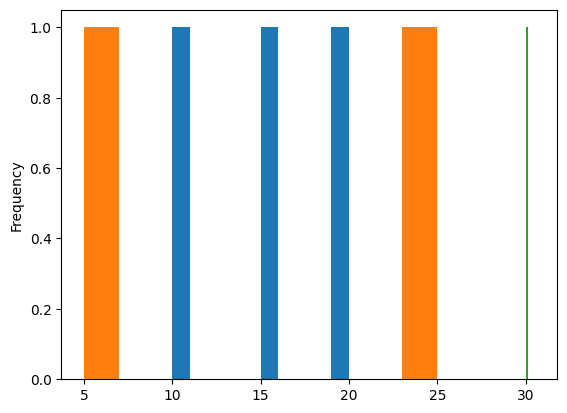

In [28]:
df.groupby("user")["score"].plot(kind = "hist")

In [29]:
df = pd.DataFrame({
    "A": [1,2,3],
    "B": [4,5,6]
})

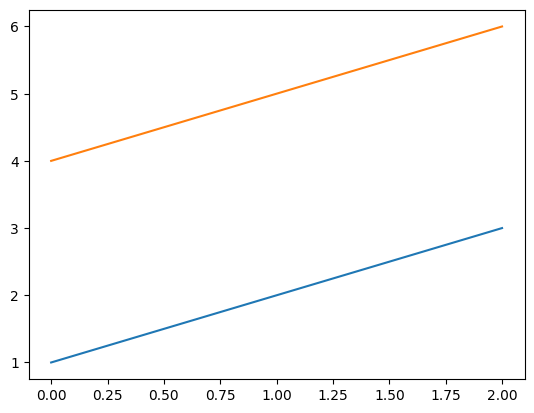

In [30]:
plt.plot(df.index, df["A"])
plt.plot(df.index, df["B"])

In [31]:
plt.boxplot(df["score"])
plt.title("Score Distribution")
plt.show()

KeyError: 'score'

In [32]:
df = pd.DataFrame({
    "user": ["A","A","A","B","B","C"],
    "day": [1,2,3,1,2,1],
    "score": [10,20,15,5,25,30]
})

In [33]:
data = df.groupby("user")["score"].sum()

In [35]:
data

user
A    45
B    30
C    30
Name: score, dtype: int64

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.


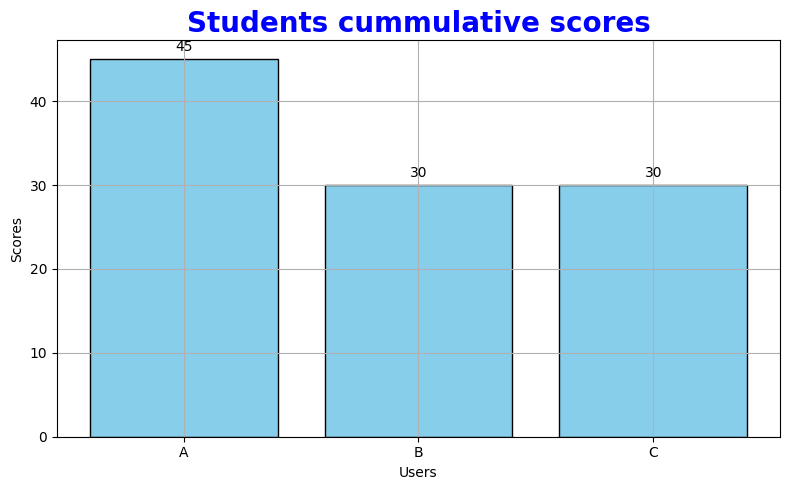

In [51]:
plt.figure(figsize=(8,5))
plt.bar(data.index,data.values,color = "skyblue",edgecolor = "black")
for i,v in enumerate(data.values):
    plt.text(i,v+1,str(v),ha="center")
plt.title("Students cummulative scores",fontsize = 20,fontweight = "bold",family = "Arial",color = "blue")
plt.xlabel("Users")
plt.ylabel("Scores")
plt.grid()
plt.tight_layout()
plt.show()

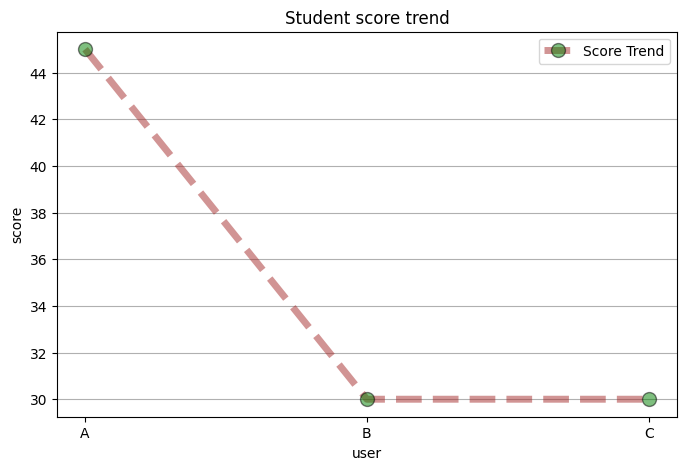

In [52]:
plt.figure(figsize=(8,5))
plt.plot(data.index,data.values,marker = ".",mfc = "green",mec = "black",ms = 20,linestyle = "dashed",linewidth = 5,color = "brown",alpha = 0.5,label= "Score Trend")
plt.legend()
plt.title("Student score trend")
plt.xlabel("user")
plt.ylabel("score")
plt.grid(axis = "y")
plt.show()


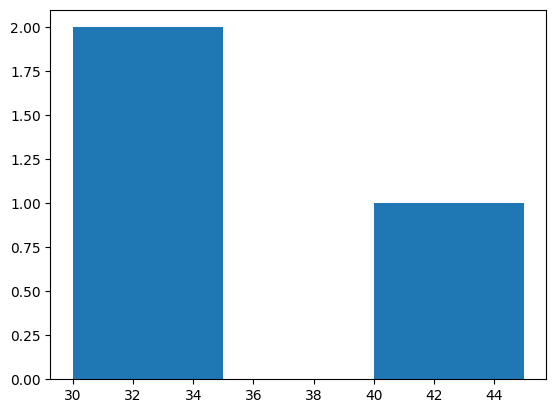

In [50]:
plt.hist(data.values,bins = 3)
plt.show()

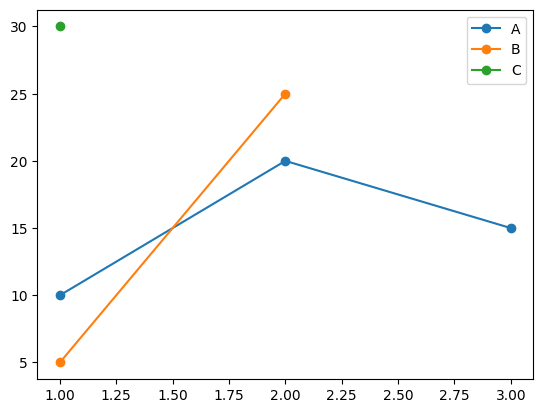

In [56]:
for user, group in df.groupby("user"):
    plt.plot(group["day"], group["score"], marker="o", label=user)
plt.legend()
plt.show()


In [54]:
for user, group in df.groupby("user"):
    print(user)
    print(group)

A
  user  day  score
0    A    1     10
1    A    2     20
2    A    3     15
B
  user  day  score
3    B    1      5
4    B    2     25
C
  user  day  score
5    C    1     30


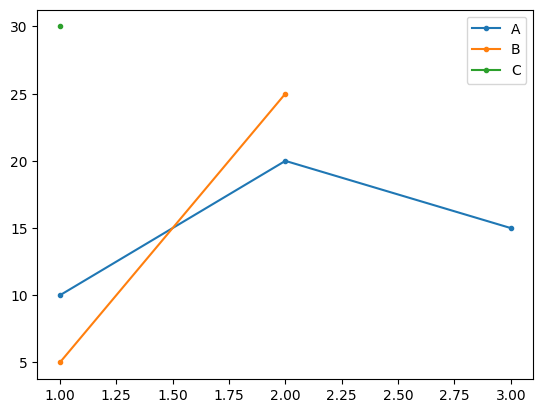

In [60]:
for user,group in df.groupby("user"):
    plt.plot(group["day"],group["score"],marker = '.',label = user)
plt.legend()
plt.show()

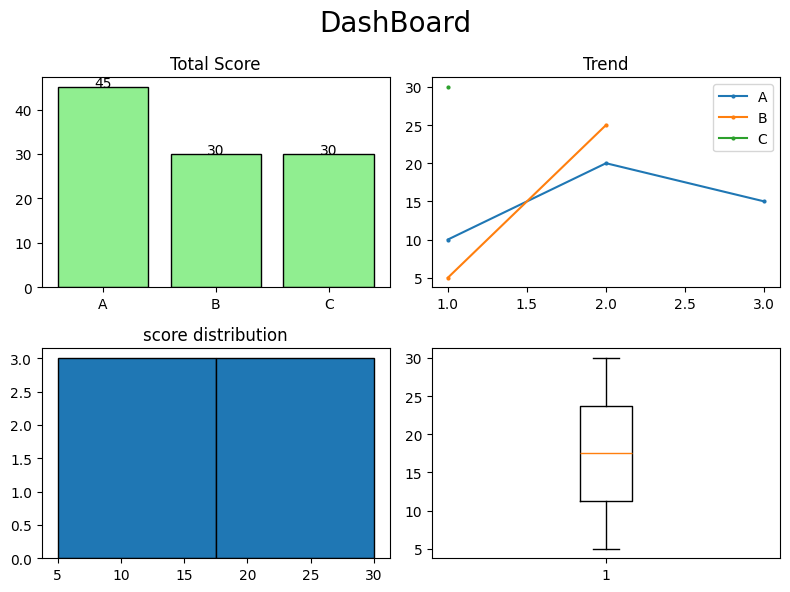

In [86]:
figure,axes = plt.subplots(2,2,figsize = (8,6))

for i,v in enumerate(data.values):
   axes[0,0].text(i,v,str(v),ha = "center")
axes[0,0].bar(data.index,data.values,color = "lightgreen",edgecolor = "black")
axes[0,0].set_title("Total Score")

for user,group in df.groupby("user"):
    axes[0,1].plot(group["day"],group["score"],marker = ".",markersize = 4,label = user)
axes[0,1].legend()
axes[0,1].set_title("Trend")

axes[1,0].hist(df["score"],bins = 2,edgecolor = "black")
axes[1,0].set_title("score distribution")

axes[1,1].boxplot(df["score"])
figure.suptitle("DashBoard",fontsize = 20)
plt.tight_layout()
plt.show()

In [87]:
df = pd.DataFrame({
    "salary": [20, 35, 50, 70, 90]
})

In [88]:
df["category"] = pd.cut(
    df["salary"],
    bins = [0,40,70,100],
    labels=["low","medium","high"]
)
df

,salary,category
0,20,low
1,35,low
2,50,medium
3,70,medium
4,90,high


In [89]:
df["category"].value_counts()

category
low       2
medium    2
high      1
Name: count, dtype: int64

In [1]:
import pandas as pd

df = pd.DataFrame({
    "marks": [10, 20, 30, 40, 50, 60, 70, 80]
})

df["quartile"] = pd.qcut(df["marks"], q=4)
print(df)

   marks       quartile
0     10  (9.999, 27.5]
1     20  (9.999, 27.5]
2     30   (27.5, 45.0]
3     40   (27.5, 45.0]
4     50   (45.0, 62.5]
5     60   (45.0, 62.5]
6     70   (62.5, 80.0]
7     80   (62.5, 80.0]


In [6]:
df = pd.DataFrame({
    "marks" : [40,75,90]
})
df["grade"] = df["marks"].map({
    40: "C",
    75: "B",
    90: "A"
})

In [7]:
df

,marks,grade
0,40,C
1,75,B
2,90,A


In [ ]:
df = pd.DataFrame({
    "danger" : [1,2,3]
})
df["dan_category"] = df["danger"].map({
    1 : 'low',
    2 : "medium",
    3 : "high"
})

In [11]:
df

,danger,dan_category
0,1,low
1,2,medium
2,3,high


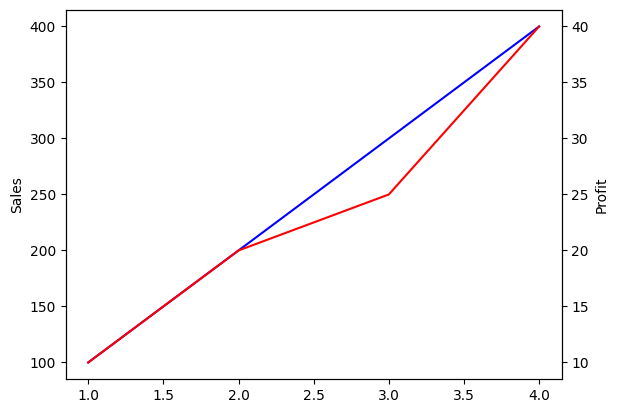

In [1]:
import matplotlib.pyplot as plt

x = [1,2,3,4]
sales = [100, 200, 300, 400]
profit = [10, 20, 25, 40]

fig, ax1 = plt.subplots()

ax1.plot(x, sales, color="blue", label="Sales")
ax1.set_ylabel("Sales")

ax2 = ax1.twinx()   # 🔥 second y-axis

ax2.plot(x, profit, color="red", label="Profit")
ax2.set_ylabel("Profit")

plt.show()

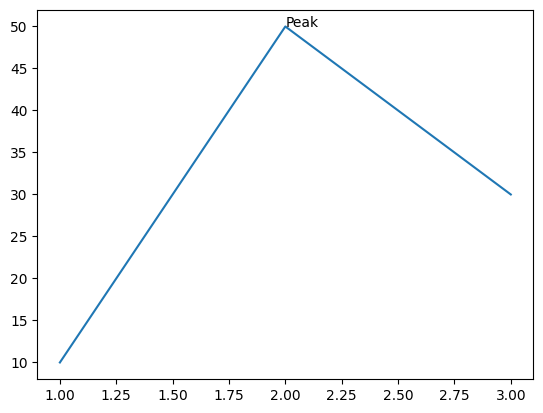

In [2]:
plt.plot([1,2,3], [10,50,30])

plt.annotate("Peak", (2,50))

plt.show()

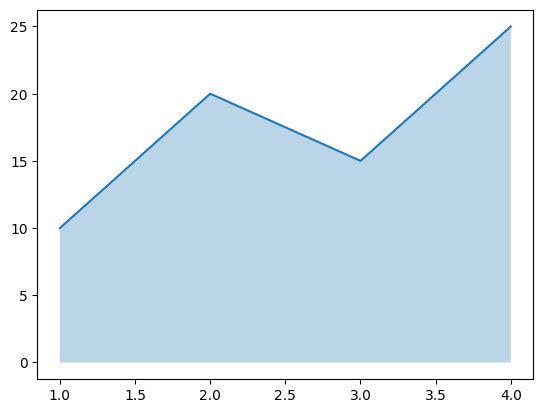

In [3]:
x = [1,2,3,4]
y = [10,20,15,25]

plt.plot(x, y)
plt.fill_between(x, y, alpha=0.3)

plt.show()

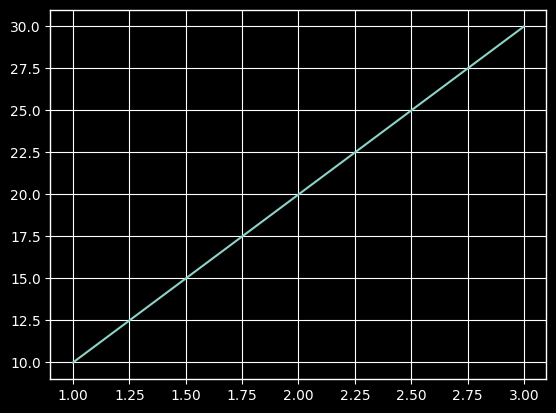

In [7]:
#plt.style.use("ggplot")
#plt.style.use("seaborn")
plt.style.use("dark_background")
plt.plot([1,2,3], [10,20,30])
plt.show()

In [1]:
import pandas as pd
df = pd.DataFrame({
    "name" : ['A','B','C','D'],
    "marks" : [35,80,65,20]
})

In [2]:
df

,name,marks
0,A,35
1,B,80
2,C,65
3,D,20


In [4]:
df["result"] = df["marks"] >= 40

In [5]:
df

,name,marks,result
0,A,35,False
1,B,80,True
2,C,65,True
3,D,20,False


In [6]:
df["grade"] = df["marks"].apply(
    lambda x : 'A' if x >= 75 else('B' if 74 <= x <= 50  else 'C')
)

In [7]:
df

,name,marks,result,grade
0,A,35,False,C
1,B,80,True,A
2,C,65,True,C
3,D,20,False,C


In [8]:
import pandas as pd

df = pd.DataFrame({
    "product": ["A", "B", "C", "D"],
    "price": [100, 200, 150, 300],
    "quantity": [2, 1, 4, 2]
})

In [9]:
df

,product,price,quantity
0,A,100,2
1,B,200,1
2,C,150,4
3,D,300,2


In [10]:
df["total"] = df["price"] * df["quantity"]

In [11]:
df["expensive"] = ["Yes" if x > 150 else "No" for x in df["price"] ]

In [13]:
df.loc[df["total"] > 300]

,product,price,quantity,total,expensive
2,C,150,4,600,No
3,D,300,2,600,Yes


In [14]:
df

,product,price,quantity,total,expensive
0,A,100,2,200,No
1,B,200,1,200,Yes
2,C,150,4,600,No
3,D,300,2,600,Yes
